In [21]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

print(f'PyTorch version : {torch.__version__}')
print(f'GPU available   : {torch.cuda.is_available()}')

PyTorch version : 2.10.0+cu128
GPU available   : True


In [22]:
# Cell 2 — Load dataset
df = pd.read_csv('/kaggle/input/datasets/manisha1prakash/marathi-dataset/Marathi_DM_Proj.csv')

df['label'] = df['label'].astype(str).str.strip()
df['label'] = df['label'].map({'1': 'Happy', '0': 'Neutral', '-1': 'Sad'})

print(f'Dataset Shape: {df.shape}')
print(f'\nLabel Distribution:')
print(df['label'].value_counts())
print(f'\nSample rows:')
display(df.head(10))

Dataset Shape: (1500, 2)

Label Distribution:
label
Happy      500
Neutral    500
Sad        500
Name: count, dtype: int64

Sample rows:


,tweet,label
0,कोरोना काळात आपले पंतप्रधान मा. नरेंद्र मोदी...,Happy
1,पुणे येथे राष्ट्रसेवा दल अभ्यासिका विभाग यां...,Happy
2,"पुणे येथील ""क्रांती ज्योती"" या कार्यक्रमात ज...",Neutral
3,आद्यक्रांतिकारक उमाजीराजे नाईक यांना जयंतीनि...,Happy
4,महाराष्ट्राचे मुख्यमंत्री म्हणून शपथ घेतल्या...,Happy
5,अधुनिक भारताचे पहिले समाजक्रांतिकारक महात्मा...,Happy
6,दीपावली लक्ष्मीपूजनानिमित्त आज परळी शहरातील ...,Happy
7,महाराष्ट्र खऱ्या अर्थाने हागणदारीमुक्त व्हाव...,Sad
8,"Wishing everyone a very prosperous, healthy ...",Happy
9,औरंगाबाद मध्य विधानसभा मतदार संघामध्ये अब्दु...,Neutral


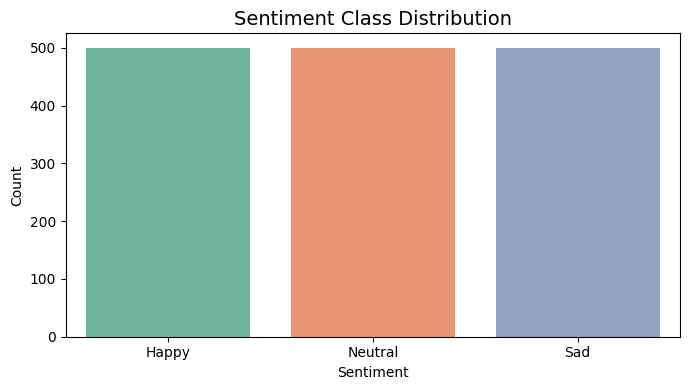

In [23]:
# Cell 3 — Plot class distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='label', hue='label',
              order=['Happy', 'Neutral', 'Sad'],
              palette='Set2', legend=False)
plt.title('Sentiment Class Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [24]:
# Cell 4 — Encode labels and split dataset
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])
label_names = le.classes_.tolist()   # ['Happy', 'Neutral', 'Sad']
num_labels  = len(label_names)

print(f'Label mapping : {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'Number of classes: {num_labels}')

X = df['tweet'].tolist()
y = df['encoded_label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'\nSplit → Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

Label mapping : {'Happy': np.int64(0), 'Neutral': np.int64(1), 'Sad': np.int64(2)}
Number of classes: 3

Split → Train: 1050, Val: 225, Test: 225


In [25]:
# Cell 5 — Dataset class
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

print('Dataset class ready!')

Dataset class ready!


In [26]:
# Cell 6 — Train and Evaluate helper functions
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in dataloader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['labels'].to(device)

        optimizer.zero_grad()
        out = model(input_ids=ids, attention_mask=mask, labels=lbls)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += out.loss.item()
        preds = torch.argmax(out.logits, dim=1)
        correct += (preds == lbls).sum().item()
        total   += lbls.size(0)
    return total_loss / len(dataloader), correct / total


def evaluate(model, dataloader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in dataloader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['labels'].to(device)

            out = model(input_ids=ids, attention_mask=mask, labels=lbls)
            total_loss += out.loss.item()
            preds = torch.argmax(out.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(dataloader), acc, f1, all_preds, all_labels

print('Helper functions ready!')

Helper functions ready!


In [27]:
# Cell 7 — Main run_model function (30 epochs, no early stopping, graphs for every model)
def run_model(model_name, display_name,
              X_train, y_train, X_val, y_val, X_test, y_test,
              num_labels, label_names,
              epochs=30, batch_size=16, lr=2e-5, max_len=128):

    print(f"\n{'='*60}")
    print(f'  Running : {display_name}')
    print(f'  Model ID: {model_name}')
    print(f"{'='*60}")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'  Device  : {device}')

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
                model_name, num_labels=num_labels, ignore_mismatched_sizes=True)
    model.to(device)

    use_gpu = device.type == 'cuda'
    train_dl = DataLoader(EmotionDataset(X_train, y_train, tokenizer, max_len),
                          batch_size=batch_size, shuffle=True,
                          num_workers=0, pin_memory=use_gpu)
    val_dl   = DataLoader(EmotionDataset(X_val,   y_val,   tokenizer, max_len),
                          batch_size=batch_size,
                          num_workers=0, pin_memory=use_gpu)
    test_dl  = DataLoader(EmotionDataset(X_test,  y_test,  tokenizer, max_len),
                          batch_size=batch_size,
                          num_workers=0, pin_memory=use_gpu)

    optimizer   = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_dl) * epochs
    scheduler   = get_linear_schedule_with_warmup(
                      optimizer,
                      num_warmup_steps=total_steps // 10,
                      num_training_steps=total_steps)

    best_val_acc, best_state = 0, None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc               = train_epoch(model, train_dl, optimizer, scheduler, device)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_dl, device)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        print(f'  Epoch {epoch}/{epochs} | '
              f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | '
              f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}  F1: {vl_f1:.4f}')

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    # Test with best checkpoint
    model.load_state_dict(best_state)
    _, ts_acc, ts_f1, ts_preds, ts_labels = evaluate(model, test_dl, device)

    print(f'\n  Test Accuracy      : {ts_acc:.4f}')
    print(f'  Test F1 (weighted) : {ts_f1:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(ts_labels, ts_preds, target_names=label_names))

    # Save best model
    safe_name = display_name.replace(' ', '_')
    model.save_pretrained(f'/kaggle/working/saved_{safe_name}')
    tokenizer.save_pretrained(f'/kaggle/working/saved_{safe_name}')
    print(f'  Saved to /kaggle/working/saved_{safe_name}')

    # Confusion matrix
    cm = confusion_matrix(ts_labels, ts_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix — {display_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/cm_{safe_name}.png', dpi=150)
    plt.show()

    # Training & Validation Loss and Accuracy graphs
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_loss'], marker='o', color='steelblue', label='Train Loss')
    ax1.plot(history['val_loss'],   marker='o', color='orange',    label='Val Loss')
    ax1.set_title(f'{display_name} — Training & Validation Loss', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_acc'], marker='o', color='steelblue', label='Train Accuracy')
    ax2.plot(history['val_acc'],   marker='o', color='orange',    label='Val Accuracy')
    ax2.set_title(f'{display_name} — Training & Validation Accuracy', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/curve_{safe_name}.png', dpi=150)
    plt.show()

    # Free GPU memory before next model
    del model
    torch.cuda.empty_cache()

    return {
        'model_name':    display_name,
        'test_accuracy': round(ts_acc, 4),
        'test_f1':       round(ts_f1, 4),
        'best_val_acc':  round(best_val_acc, 4)
    }

print('run_model function ready!')

run_model function ready!



  Running : mBERT
  Model ID: bert-base-multilingual-cased
  Device  : cuda


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/30 | Train Loss: 1.0949  Acc: 0.3543 | Val Loss: 1.0343  Acc: 0.4800  F1: 0.4232
  Epoch 2/30 | Train Loss: 0.8508  Acc: 0.6343 | Val Loss: 0.7641  Acc: 0.6756  F1: 0.6704
  Epoch 3/30 | Train Loss: 0.5760  Acc: 0.7829 | Val Loss: 0.8128  Acc: 0.7022  F1: 0.6915
  Epoch 4/30 | Train Loss: 0.4145  Acc: 0.8467 | Val Loss: 1.2318  Acc: 0.6800  F1: 0.6668
  Epoch 5/30 | Train Loss: 0.3092  Acc: 0.9029 | Val Loss: 1.4074  Acc: 0.7022  F1: 0.7023
  Epoch 6/30 | Train Loss: 0.2130  Acc: 0.9476 | Val Loss: 1.4355  Acc: 0.7333  F1: 0.7337
  Epoch 7/30 | Train Loss: 0.1170  Acc: 0.9705 | Val Loss: 1.8551  Acc: 0.7022  F1: 0.6965
  Epoch 8/30 | Train Loss: 0.1241  Acc: 0.9790 | Val Loss: 2.2922  Acc: 0.6622  F1: 0.6552
  Epoch 9/30 | Train Loss: 0.0788  Acc: 0.9829 | Val Loss: 1.8513  Acc: 0.7244  F1: 0.7241
  Epoch 10/30 | Train Loss: 0.0379  Acc: 0.9943 | Val Loss: 1.7921  Acc: 0.7422  F1: 0.7408
  Epoch 11/30 | Train Loss: 0.0265  Acc: 0.9943 | Val Loss: 1.6931  Acc: 0.7644  F1: 0.76

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved to /kaggle/working/saved_mBERT


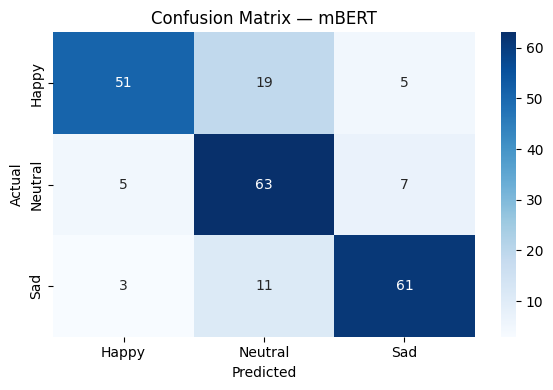

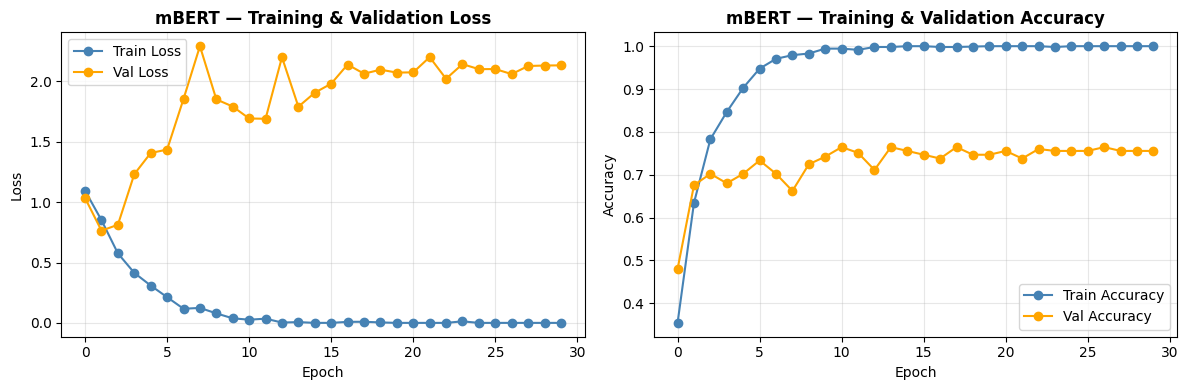

In [28]:
# Cell 8 — Run mBERT (30 epochs)
results_mbert = run_model(
    model_name='bert-base-multilingual-cased',
    display_name='mBERT',
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    num_labels=num_labels, label_names=label_names,
    epochs=30, batch_size=8, lr=2e-5
)


  Running : XLM-RoBERTa-base
  Model ID: xlm-roberta-base
  Device  : cuda


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/30 | Train Loss: 1.0975  Acc: 0.3419 | Val Loss: 1.0199  Acc: 0.5422  F1: 0.5196
  Epoch 2/30 | Train Loss: 0.8158  Acc: 0.6743 | Val Loss: 0.6599  Acc: 0.7556  F1: 0.7509
  Epoch 3/30 | Train Loss: 0.5939  Acc: 0.8057 | Val Loss: 0.6827  Acc: 0.7511  F1: 0.7485
  Epoch 4/30 | Train Loss: 0.4416  Acc: 0.8562 | Val Loss: 0.8818  Acc: 0.7467  F1: 0.7417
  Epoch 5/30 | Train Loss: 0.3439  Acc: 0.9162 | Val Loss: 1.0329  Acc: 0.7778  F1: 0.7777
  Epoch 6/30 | Train Loss: 0.2939  Acc: 0.9352 | Val Loss: 1.3923  Acc: 0.7556  F1: 0.7579
  Epoch 7/30 | Train Loss: 0.1524  Acc: 0.9657 | Val Loss: 1.6571  Acc: 0.7289  F1: 0.7273
  Epoch 8/30 | Train Loss: 0.0563  Acc: 0.9886 | Val Loss: 1.5318  Acc: 0.7822  F1: 0.7843
  Epoch 9/30 | Train Loss: 0.0661  Acc: 0.9867 | Val Loss: 1.6171  Acc: 0.7644  F1: 0.7656
  Epoch 10/30 | Train Loss: 0.0471  Acc: 0.9895 | Val Loss: 1.6432  Acc: 0.7911  F1: 0.7930
  Epoch 11/30 | Train Loss: 0.0413  Acc: 0.9933 | Val Loss: 1.8246  Acc: 0.7644  F1: 0.76

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved to /kaggle/working/saved_XLM-RoBERTa-base


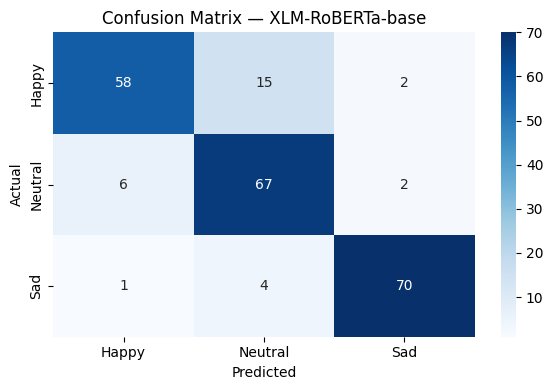

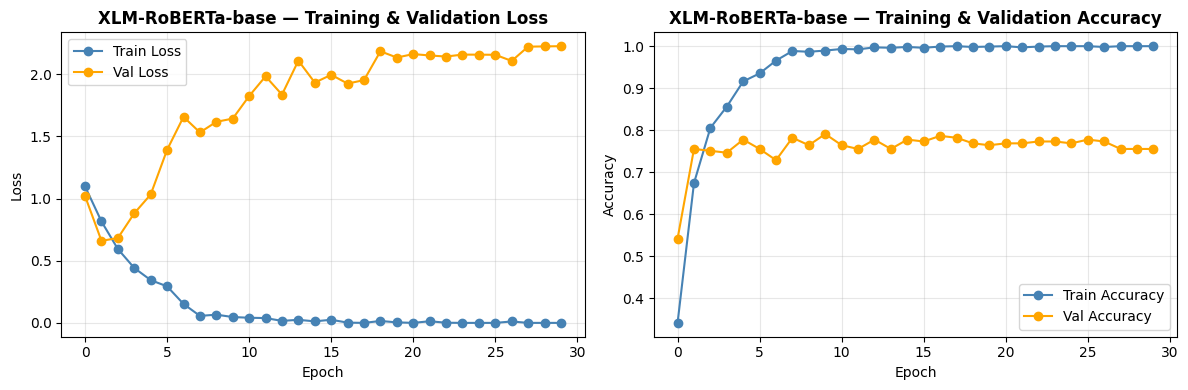

In [29]:
# Cell 9 — Run XLM-RoBERTa Base (30 epochs)
results_xlmr = run_model(
    model_name='xlm-roberta-base',
    display_name='XLM-RoBERTa-base',
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    num_labels=num_labels, label_names=label_names,
    epochs=30, batch_size=8, lr=2e-5
)


  Running : MuRIL
  Model ID: google/muril-base-cased
  Device  : cuda


config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expe

  Epoch 1/30 | Train Loss: 1.0984  Acc: 0.3333 | Val Loss: 1.0971  Acc: 0.3333  F1: 0.1667
  Epoch 2/30 | Train Loss: 1.0479  Acc: 0.6352 | Val Loss: 0.9588  Acc: 0.7867  F1: 0.7852
  Epoch 3/30 | Train Loss: 0.8482  Acc: 0.8410 | Val Loss: 0.7754  Acc: 0.7867  F1: 0.7843
  Epoch 4/30 | Train Loss: 0.6065  Acc: 0.8952 | Val Loss: 0.6219  Acc: 0.7911  F1: 0.7899
  Epoch 5/30 | Train Loss: 0.3544  Acc: 0.9429 | Val Loss: 0.5903  Acc: 0.8000  F1: 0.7990
  Epoch 6/30 | Train Loss: 0.2193  Acc: 0.9581 | Val Loss: 0.6753  Acc: 0.7956  F1: 0.7951
  Epoch 7/30 | Train Loss: 0.1160  Acc: 0.9819 | Val Loss: 0.7629  Acc: 0.7956  F1: 0.7958
  Epoch 8/30 | Train Loss: 0.0738  Acc: 0.9848 | Val Loss: 0.7730  Acc: 0.8133  F1: 0.8118
  Epoch 9/30 | Train Loss: 0.0392  Acc: 0.9952 | Val Loss: 0.8178  Acc: 0.8089  F1: 0.8075
  Epoch 10/30 | Train Loss: 0.0234  Acc: 0.9981 | Val Loss: 0.9692  Acc: 0.8000  F1: 0.7993
  Epoch 11/30 | Train Loss: 0.0220  Acc: 0.9971 | Val Loss: 1.0427  Acc: 0.7911  F1: 0.79

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved to /kaggle/working/saved_MuRIL
The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!


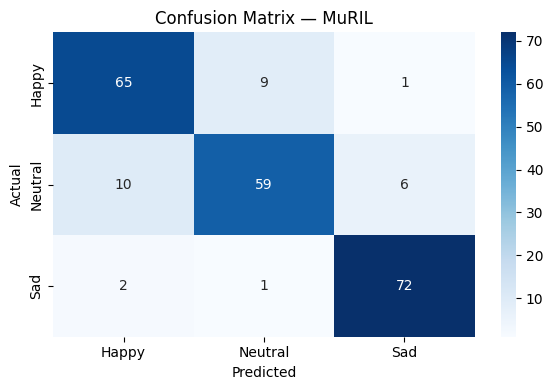

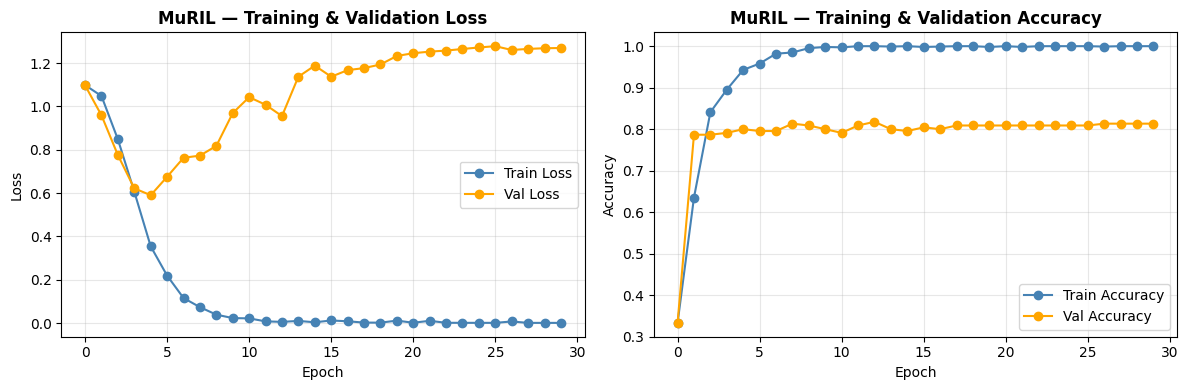

In [30]:
# Cell 10 — Run MuRIL (30 epochs)
results_muril = run_model(
    model_name='google/muril-base-cased',
    display_name='MuRIL',
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    num_labels=num_labels, label_names=label_names,
    epochs=30, batch_size=8, lr=2e-5
)


  Running : XLM-RoBERTa-large
  Model ID: xlm-roberta-large
  Device  : cuda


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/30 | Train Loss: 1.1015  Acc: 0.3467 | Val Loss: 1.0868  Acc: 0.3333  F1: 0.1667
  Epoch 2/30 | Train Loss: 0.8375  Acc: 0.6324 | Val Loss: 0.6553  Acc: 0.7689  F1: 0.7684
  Epoch 3/30 | Train Loss: 0.6295  Acc: 0.8286 | Val Loss: 0.8909  Acc: 0.7867  F1: 0.7883
  Epoch 4/30 | Train Loss: 0.5468  Acc: 0.8638 | Val Loss: 1.6547  Acc: 0.7244  F1: 0.7101
  Epoch 5/30 | Train Loss: 0.3787  Acc: 0.9295 | Val Loss: 1.2891  Acc: 0.7733  F1: 0.7745
  Epoch 6/30 | Train Loss: 0.2067  Acc: 0.9600 | Val Loss: 1.5710  Acc: 0.7778  F1: 0.7766
  Epoch 7/30 | Train Loss: 0.1404  Acc: 0.9752 | Val Loss: 1.5838  Acc: 0.7867  F1: 0.7832
  Epoch 8/30 | Train Loss: 0.0957  Acc: 0.9848 | Val Loss: 1.9649  Acc: 0.7644  F1: 0.7647
  Epoch 9/30 | Train Loss: 0.0700  Acc: 0.9895 | Val Loss: 1.7640  Acc: 0.7911  F1: 0.7929
  Epoch 10/30 | Train Loss: 0.0363  Acc: 0.9952 | Val Loss: 2.0568  Acc: 0.7689  F1: 0.7689
  Epoch 11/30 | Train Loss: 0.0740  Acc: 0.9895 | Val Loss: 1.9366  Acc: 0.7822  F1: 0.78

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved to /kaggle/working/saved_XLM-RoBERTa-large


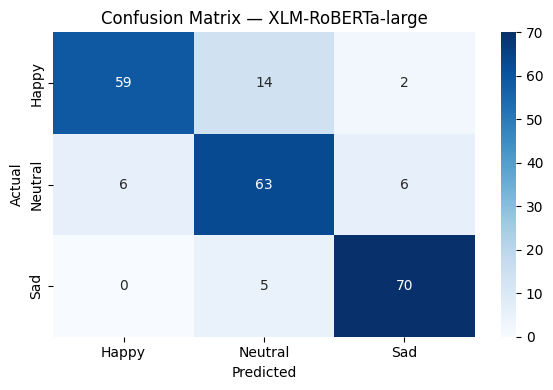

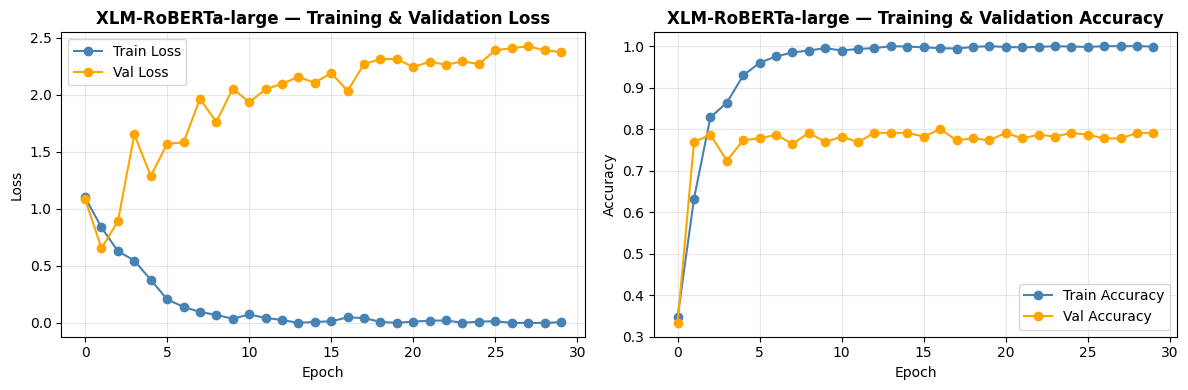

In [31]:
# Cell 11 — Run XLM-RoBERTa Large (30 epochs, smaller batch due to model size)
results_xlmr_large = run_model(
    model_name='xlm-roberta-large',
    display_name='XLM-RoBERTa-large',
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    num_labels=num_labels, label_names=label_names,
    epochs=30, batch_size=4, lr=1e-5
)

In [32]:
# Cell 12 — Compare all models
all_results = pd.DataFrame([
    results_mbert,
    results_xlmr,
    results_muril,
    results_xlmr_large
]).sort_values('test_accuracy', ascending=False).reset_index(drop=True)

print('\n===== MODEL COMPARISON =====')
print(all_results.to_string(index=False))


===== MODEL COMPARISON =====
       model_name  test_accuracy  test_f1  best_val_acc
            MuRIL         0.8711   0.8699        0.8178
 XLM-RoBERTa-base         0.8667   0.8668        0.7911
XLM-RoBERTa-large         0.8533   0.8535        0.8000
            mBERT         0.7778   0.7785        0.7644


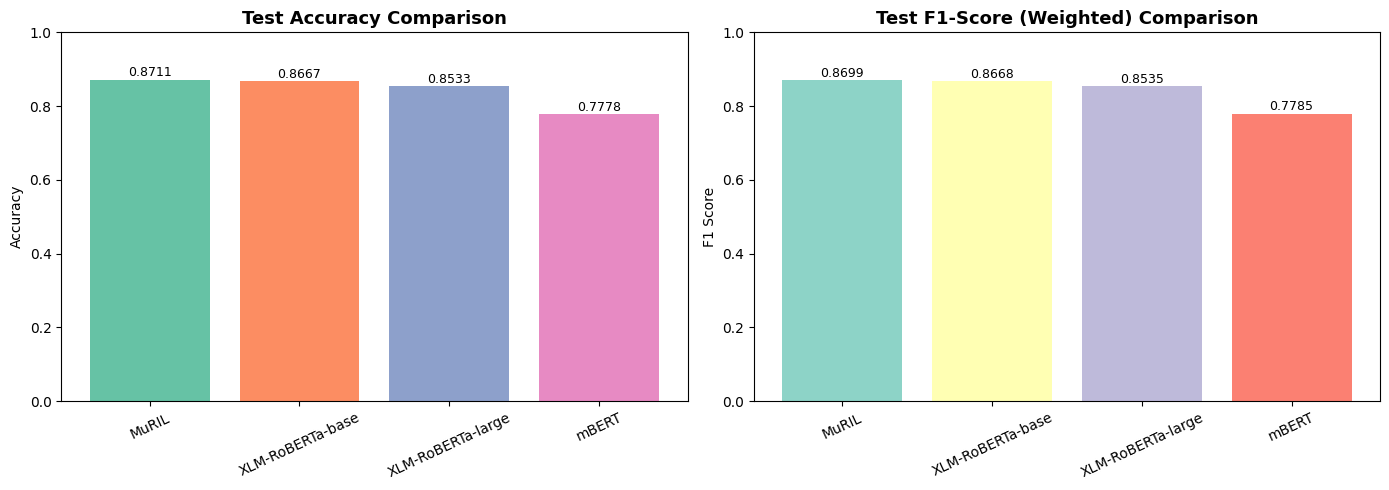


Best Model: MuRIL — Accuracy: 0.8711, F1: 0.8699


In [33]:
# Cell 13 — Plot model comparison bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('Set2', len(all_results))
bars1 = ax1.bar(all_results['model_name'], all_results['test_accuracy'], color=colors)
ax1.set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=25)
for bar, val in zip(bars1, all_results['test_accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontsize=9)

bars2 = ax2.bar(all_results['model_name'], all_results['test_f1'],
                color=sns.color_palette('Set3', len(all_results)))
ax2.set_title('Test F1-Score (Weighted) Comparison', fontsize=13, fontweight='bold')
ax2.set_ylabel('F1 Score')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=25)
for bar, val in zip(bars2, all_results['test_f1']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=150)
plt.show()

best = all_results.iloc[0]
print(f"\nBest Model: {best['model_name']} — Accuracy: {best['test_accuracy']:.4f}, F1: {best['test_f1']:.4f}")

In [34]:
# Cell 14 — Load best model and run predictions on sample Marathi sentences
def predict_sentiment(texts, model, tokenizer, device, label_names):
    model.eval()
    results = []
    for text in texts:
        enc = tokenizer(text, max_length=128, padding='max_length',
                        truncation=True, return_tensors='pt')
        ids  = enc['input_ids'].to(device)
        mask = enc['attention_mask'].to(device)
        with torch.no_grad():
            out = model(input_ids=ids, attention_mask=mask)
        probs = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
        results.append({
            'text':       text[:80] + ('...' if len(text) > 80 else ''),
            'sentiment':  label_names[probs.argmax()],
            'confidence': f'{probs.max()*100:.1f}%'
        })
    return pd.DataFrame(results)


# Load whichever model scored best
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model_name = all_results.iloc[0]['model_name'].replace(' ', '_')

inf_tokenizer = AutoTokenizer.from_pretrained(f'/kaggle/working/saved_{best_model_name}')
inf_model     = AutoModelForSequenceClassification.from_pretrained(f'/kaggle/working/saved_{best_model_name}')
inf_model.to(device)
inf_model.eval()
print(f"Loaded: {all_results.iloc[0]['model_name']}")

# Sample Marathi sentences
test_sentences = [
    'आज खूप आनंद झाला! हे खूप छान आहे!',
    'आज काहीच विशेष नाही, सगळं नेहमीसारखं आहे.',
    'मला खूप दुःख होत आहे, कोणी नाही माझ्यासाठी.',
    'हे खरोखरच अविश्वसनीय आहे!',
    'आज हवामान ठीक आहे.',
]

preds = predict_sentiment(test_sentences, inf_model, inf_tokenizer, device, label_names)
print(preds.to_string(index=False))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded: MuRIL
                                       text sentiment confidence
          आज खूप आनंद झाला! हे खूप छान आहे!     Happy      99.6%
  आज काहीच विशेष नाही, सगळं नेहमीसारखं आहे.     Happy      99.5%
मला खूप दुःख होत आहे, कोणी नाही माझ्यासाठी.       Sad      99.6%
                  हे खरोखरच अविश्वसनीय आहे!       Sad      99.6%
                         आज हवामान ठीक आहे.     Happy      99.5%
